## Lab 9: Deep Learning for Bird Species Classification

**Data source:** iNaturalist API (research-grade observations, California species)

In this lab we demonstrate how to fit a convolutional neural network (CNN) for image classification using PyTorch, following the approach in Section 10.9 of the textbook. Rather than the CIFAR100 benchmark, we work with real biodiversity data: photographs of 10 California bird species downloaded directly from the **iNaturalist** API.

iNaturalist hosts over 200 million research-grade wildlife observations contributed by citizen scientists. The computer vision models powering iNaturalist's "Suggest an ID" feature are CNNs trained on exactly this kind of data. By building one yourself, you will understand both the technical pipeline and its practical limitations for species monitoring at scale.

We start with several standard imports that we have seen before.

In [25]:
import os
import time
import requests                                    # HTTP requests to the iNaturalist API
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from io import BytesIO                             # Hold image bytes in memory without saving to disk first
from PIL import Image                              # Open and convert downloaded images
from concurrent.futures import ThreadPoolExecutor  # Download multiple images simultaneously

### New libraries! Let's review what they do: 
- `torchinfo` provides a useful `summary()` function that neatly summarizes the layers of a model.
- `ImageFolder` from `torchvision` loads an image dataset organized as a directory of class-labeled subdirectories.
- `Compose`, `Resize`, `ToTensor`, and `Normalize` transforms are applied to each image as it is loaded.
- `random_split` partitions a dataset into non-overlapping subsets.
- `SimpleDataModule`, `SimpleModule`, `ErrorTracker`, and `rec_num_workers` from `ISLP.torch` handle data loading, training, and validation following the textbook pattern.
- `Trainer` from `pytorch_lightning` orchestrates the full training loop; `CSVLogger` records metrics to a CSV file.
- `RMSprop` is the optimizer used for image data (experiments show a lower learning rate performs better than the default).

In [26]:
import torch
from torch import nn                           # Neural network layers and loss functions
from torch.utils.data import random_split
from torch.optim import RMSprop
from torchinfo import summary                  # Prints a layer-by-layer model summary
from torchvision.datasets import ImageFolder   # Loads images from a class-labeled directory tree
from torchvision.transforms import Resize, ToTensor, Normalize, Compose
from ISLP.torch import (SimpleDataModule,
                        SimpleModule,
                        ErrorTracker,
                        rec_num_workers)
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import CSVLogger

torch.manual_seed(0)  # Fix random seed for reproducibility

### Downloading Bird Images from iNaturalist

The iNaturalist open API allows anyone to query millions of georeferenced species observations. We filter for **research-grade** records, the highest-quality tier, where multiple community members have agreed on the species identification. 

We define a dictionary mapping folder names (used as class labels) to scientific taxon names. For each species we make one API call to retrieve up to 200 observation records, extract the photo URL from each, then download the images in parallel using `ThreadPoolExecutor` to significantly reduce the download time. 

Photos are saved to `data/inat_birds/<species>/`. Unlike a lot of instances in Python, re-running this cell is safe! It skips any image file that already exists on the disk. This also means that after running it the first time ( ~ 3 minutes), the images will instantly be available any time in the future. 

In [ ]:
SPECIES = {
    'annas_hummingbird':     'Calypte anna',
    'california_scrub_jay':  'Aphelocoma californica',
    'acorn_woodpecker':      'Melanerpes formicivorus',
    'great_blue_heron':      'Ardea herodias',
    'red_tailed_hawk':       'Buteo jamaicensis',
    'mallard':               'Anas platyrhynchos',
    'brown_pelican':         'Pelecanus occidentalis',
    'common_raven':          'Corvus corax',
    'american_robin':        'Turdus migratorius',
    'white_crowned_sparrow': 'Zonotrichia leucophrys'
}

SAVE_ROOT     = 'data/inat_birds'
N_PER_SPECIES = 200


def fetch_photo_urls(taxon_name, n=200):
    params = {
        'taxon_name':    taxon_name,
        'photos':        'true',
        'quality_grade': 'research',
        'license':       'cc-by,cc-by-nc,cc-by-sa,cc-by-nc-sa',
        'per_page':      min(n, 200),
        'page':          1
    }
    resp    = requests.get('https://api.inaturalist.org/v1/observations', params=params, timeout=30)
    results = resp.json().get('results', [])
    return [(obs['photos'][0]['url'].replace('square', 'medium'), obs['id'])
            for obs in results if obs.get('photos')]


def download_one(args):
    url, save_path = args
    if os.path.exists(save_path):
        return True
    try:
        resp = requests.get(url, timeout=15)
        if resp.status_code == 200:
            Image.open(BytesIO(resp.content)).convert('RGB').save(save_path)
            return True
    except Exception:
        pass
    return False


for folder_name, taxon_name in SPECIES.items():
    save_dir = os.path.join(SAVE_ROOT, folder_name)
    os.makedirs(save_dir, exist_ok=True)
    tasks = [(url, os.path.join(save_dir, f"{obs_id}.jpg"))
             for url, obs_id in fetch_photo_urls(taxon_name, n=N_PER_SPECIES)]
    with ThreadPoolExecutor(max_workers=10) as executor:
        results = list(executor.map(download_one, tasks))
    print(f"{folder_name}: {sum(results)}/{len(tasks)} images")

### Loading the Image Data

Our first step is to retrieve the training and test datasets. `ImageFolder` automatically assigns integer class labels based on the alphabetical order of subdirectory names. Unlike the CIFAR100 and MNIST datasets built into `torchvision`, iNaturalist images vary in size, aspect ratio, and lighting since they are real citizen-science photographs. We therefore apply three preprocessing transforms to each image as it is loaded:

1. **Resize** to 64×64 pixels, giving every image the same spatial dimensions
2. **ToTensor** converts the PIL image to a float tensor with values in [0, 1] and reorders the axes to [channels, height, width]
3. **Normalize** subtracts the ImageNet channel means and divides by the ImageNet standard deviations. This is a standard choice that centers the distribution of pixel values and has been shown to speed up convergence

In [28]:
# Transforms are applied in sequence to every image as it is loaded
transform = Compose([
    Resize((64, 64)),                                         # Standardize spatial size across all images
    ToTensor(),                                               # PIL image → float tensor, axes reordered to [C, H, W]
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet channel statistics
])

# ImageFolder assigns integer class labels based on alphabetical subdirectory order
full_dataset = ImageFolder(root=SAVE_ROOT, transform=transform)

print(f'Total images: {len(full_dataset)}')
print(f'Classes ({len(full_dataset.classes)}): {full_dataset.classes}')

Total images: 2000
Classes (10): ['acorn_woodpecker', 'american_robin', 'annas_hummingbird', 'brown_pelican', 'california_scrub_jay', 'common_raven', 'great_blue_heron', 'mallard', 'red_tailed_hawk', 'white_crowned_sparrow']


We split the full dataset into training (85%) and test (15%) subsets using `random_split`, fixing the `Generator` seed for reproducibility. We then pass both to `SimpleDataModule`, which automatically carves out 20% of the training data as a validation set — matching the textbook pattern exactly. `rec_num_workers()` queries the machine to find the optimal number of parallel data-loading processes.

In [42]:
n_total = len(full_dataset)
n_test  = int(0.15 * n_total)
n_train = n_total - n_test

bird_train, bird_test = random_split(
    full_dataset, [n_train, n_test],
    generator=torch.Generator().manual_seed(0)
)

max_num_workers = rec_num_workers()
bird_dm = SimpleDataModule(bird_train,
                           bird_test,
                           validation=0.2,
                           num_workers=max_num_workers,
                           batch_size=32)

print(f'Train: {len(bird_train)}  |  Test: {len(bird_test)}')

Train: 2256  |  Test: 398


Let's take a look at the data that will get fed into our network. We loop through the first two batches of the training data loader, breaking after 2 batches:

In [30]:
for idx, (X_, Y_) in enumerate(bird_dm.train_dataloader()):
    print('X: ', X_.shape)  # [batch_size, channels, height, width]
    print('Y: ', Y_.shape)  # [batch_size]; one integer class label per image
    if idx >= 1:
        break

X:  torch.Size([32, 3, 64, 64])
Y:  torch.Size([32])
X:  torch.Size([32, 3, 64, 64])
Y:  torch.Size([32])


We see that the `X` for each batch consists of 32 images of size 3×64×64. Here the 3 indicates three RGB color channels (the same structure as CIFAR100 images in the textbook). The `Y` tensor holds one integer class label per image.

Before we start building the network, lets look at some sample images from the dataset. So that images look normal to us, we will reverse the normalization we performed earlier and store the results in `bird_dsplay`. 

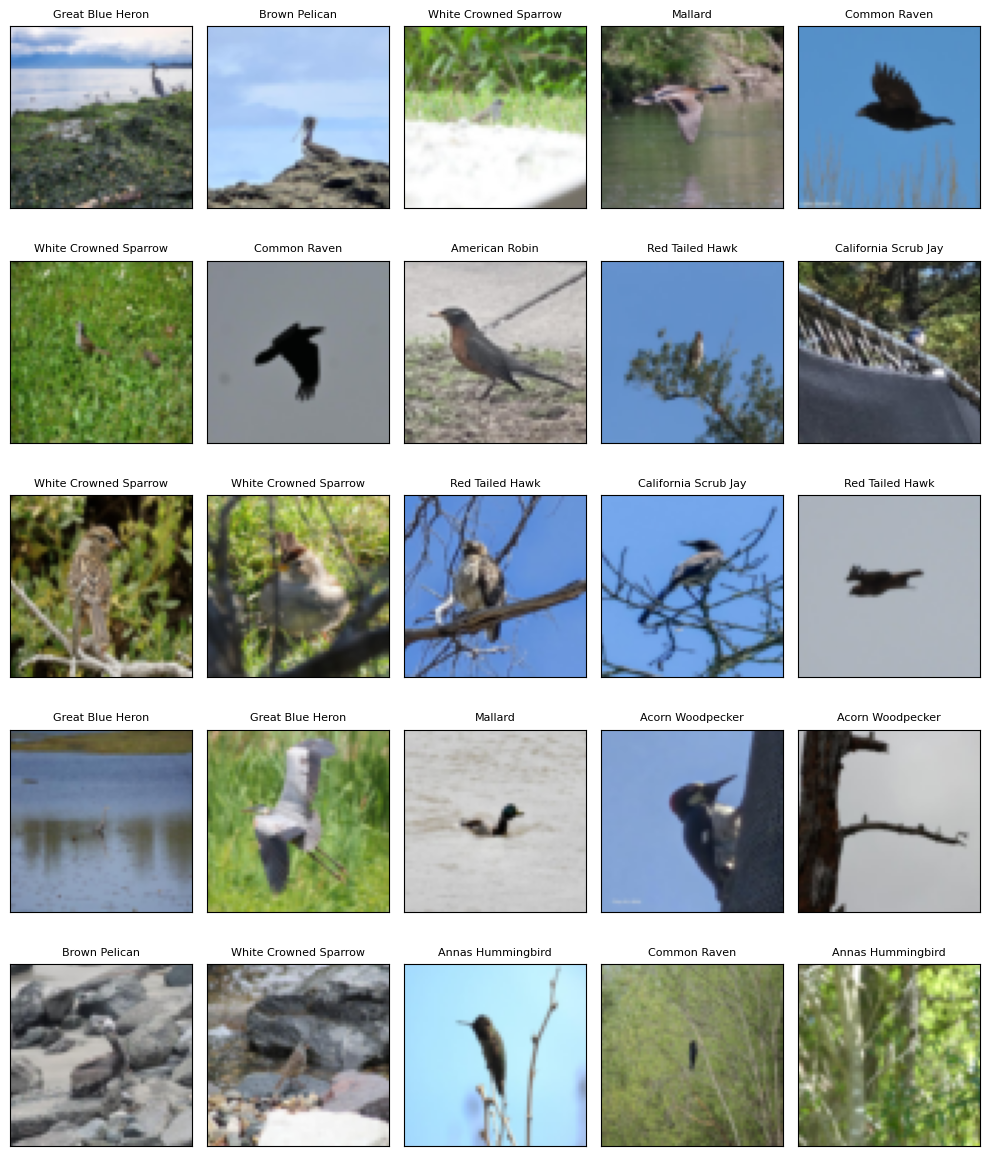

In [31]:
# Load images without Normalize so pixel values stay in [0, 1] (normalized images look washed out)
bird_display = ImageFolder(root=SAVE_ROOT,
                           transform=Compose([Resize((64, 64)), ToTensor()]))

fig, axes = subplots(5, 5, figsize=(10, 12))
rng     = np.random.default_rng(4)
indices = rng.choice(np.arange(len(bird_display)), 25,
                     replace=False).reshape((5, 5))

for i in range(5):
    for j in range(5):
        idx = indices[i, j]
        img, label = bird_display[idx]
        # np.transpose reorders axes from [C, H, W] → [H, W, C], which imshow requires
        axes[i, j].imshow(np.transpose(img, [1, 2, 0]), interpolation=None)
        axes[i, j].set_title(bird_display.classes[label].replace('_', ' ').title(),
                              fontsize=8)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

fig.tight_layout()

### Specifying a Network: Classes and Inheritance

To fit the neural network, we first set up a model structure that describes the network. Doing so requires us to define new classes specific to the model we wish to fit. Typically this is done in PyTorch by sub-classing a generic representation of a network, `nn.Module`, which is the approach we take here.

Indented beneath the `class` statement are two methods: `__init__` and `forward`. The `__init__` method is called when an instance of the class is created. In the methods, `self` always refers to an instance of the class. In `__init__`, we attach objects to `self` as attributes; these are used in the `forward` method to describe the map that this module implements.

There is one additional line in `__init__` — a call to `super()`. This function allows subclasses to access methods of the class they inherit from. For torch models, we will always make this `super()` call, as it is necessary for the model to be properly interpreted by torch.

We specify a moderately-sized CNN, similar in structure to Figure 10.8 in the textbook. We use several layers, each consisting of convolution, ReLU, and max-pooling steps. We first define a module that defines one of these layers, a `BuildingBlock`, that can be combined in other modules just like `nn.Linear()` or `nn.Dropout()`.

In [32]:
class BuildingBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(BuildingBlock, self).__init__()
        # Padding='same' keeps spatial dimensions unchanged after convolution
        self.conv = nn.Conv2d(in_channels=in_channels,
                              out_channels=out_channels,
                              kernel_size=(3, 3),
                              padding='same')
        self.activation = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(2, 2))  # Halves both height and width

    def forward(self, x):
        return self.pool(self.activation(self.conv(x)))

Each `BuildingBlock` learns to detect visual features (edges, textures, color patterns) in its input, then uses max-pooling to shrink the image by half. After stacking three blocks, our 64×64 image has been compressed down to an 8×8 grid with 128 feature channels. We then flatten that into a single vector of 8,192 values and pass it through two fully-connected layers to produce a score for each of the 10 bird species.

In [33]:
class BirdModel(nn.Module):
    def __init__(self):
        super(BirdModel, self).__init__()
        # Three blocks: channels grow 3→32→64→128; spatial dims shrink 64→32→16→8
        sizes = [(3, 32), (32, 64), (64, 128)]
        self.conv = nn.Sequential(*[BuildingBlock(in_, out_)
                                    for in_, out_ in sizes])
        self.output = nn.Sequential(
            nn.Dropout(0.5),              # Randomly zero 50% of units during training to reduce overfitting
            nn.Linear(128 * 8 * 8, 512), # Flatten 128 feature maps of size 8×8 into 8192 inputs
            nn.ReLU(),
            nn.Linear(512, 10)            # One output score per bird species
        )

    def forward(self, x):
        val = self.conv(x)
        val = torch.flatten(val, start_dim=1)  # Collapse spatial dims, keep batch dim
        return self.output(val)

bird_model = BirdModel()

We can check that the model produces output of expected size by passing a batch through it, and use the `summary()` function to neatly display the shape and parameter count of each layer. We specify the size of the input and see the size of each tensor as it passes through the layers of the network.

In [34]:
# Pass the same batch shape we saw earlier to verify output sizes at each layer
summary(bird_model,
        input_size=X_.shape,
        col_names=['input_size', 'output_size', 'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
BirdModel                                [32, 3, 64, 64]           [32, 10]                  --
├─Sequential: 1-1                        [32, 3, 64, 64]           [32, 128, 8, 8]           --
│    └─BuildingBlock: 2-1                [32, 3, 64, 64]           [32, 32, 32, 32]          --
│    │    └─Conv2d: 3-1                  [32, 3, 64, 64]           [32, 32, 64, 64]          896
│    │    └─ReLU: 3-2                    [32, 32, 64, 64]          [32, 32, 64, 64]          --
│    │    └─MaxPool2d: 3-3               [32, 32, 64, 64]          [32, 32, 32, 32]          --
│    └─BuildingBlock: 2-2                [32, 32, 32, 32]          [32, 64, 16, 16]          --
│    │    └─Conv2d: 3-4                  [32, 32, 32, 32]          [32, 64, 32, 32]          18,496
│    │    └─ReLU: 3-5                    [32, 64, 32, 32]          [32, 64, 32, 32]          --
│    │    └─MaxPool2d: 3-6    

By studying the size of the tensors, we can confirm that the spatial dimensions halve after each max-pooling operation, exactly as expected. The largest layer by far is the first fully-connected layer `Linear(8192 → 512)`, which accounts for the majority of the trainable parameters. 

### Training the Model

We use the RMSprop optimizer with a learning rate of 0.001. Experiments show that a smaller learning rate performs better than the default for image data. The optimizer takes the model's parameters as its first argument, which informs it which values are involved in stochastic gradient descent (SGD).

`SimpleModule.classification()` wraps our `BirdModel` and automatically uses cross-entropy loss (the standard loss for multi-class classification) and tracks accuracy as a metric. `CSVLogger` records training and validation metrics to a CSV file after each epoch, which we will read back to plot training curves.

We define a `summary_plot()` helper (following the textbook) that plots training and validation curves for any logged metric over epochs. CSVLogger logs train and validation metrics at different steps, so the CSV contains NaN rows for each; `dropna` filters these before plotting.

In [35]:
def summary_plot(results,
                 ax,
                 col='loss',
                 valid_legend='Validation',
                 training_legend='Training',
                 ylabel='Loss',
                 fontsize=20):
    # Training accuracy is logged as train_{col}_epoch; loss as train_{col}
    train_col = (f'train_{col}_epoch'
                 if f'train_{col}_epoch' in results.columns
                 else f'train_{col}')
    for (column, color, label) in zip(
        [train_col, f'valid_{col}'],
        ['black', 'red'],
        [training_legend, valid_legend]
    ):
        results.dropna(subset=[column]).plot(x='epoch',
                                             y=column,
                                             label=label,
                                             marker='o',
                                             color=color,
                                             ax=ax)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    return ax

Having set up both the model and the data module, fitting this model is now almost identical to the textbook's MNIST example. `SimpleModule.classification()` uses cross-entropy loss. We supply our `RMSprop` optimizer with a learning rate of 0.001 rather than the default, since experiments show it performs better on image data. The `ErrorTracker` callback records per-epoch metrics so we can inspect them after training.

In [36]:
bird_optimizer = RMSprop(bird_model.parameters(), lr=0.001)
bird_module    = SimpleModule.classification(bird_model, num_classes=10, optimizer=bird_optimizer)
bird_logger    = CSVLogger('logs', name='Birds')

bird_trainer = Trainer(deterministic=True,
                       max_epochs=30,
                       logger=bird_logger,
                       callbacks=[ErrorTracker()])
bird_trainer.fit(bird_module, datamodule=bird_dm)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ BirdModel        │  4.3 M │ train │     0 │
│ 1 │ loss  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────┴──────────────────┴────────┴───────┴───────┘
Trainable params: 4.3 M                                                         
Non-trainable params: 0                                                         
Total params: 4.3 M                                                             
Total estimated model params size (MB): 17                                      
Modules in train mode: 20                                                       
Modules in eval mode: 0                                                         
Total FLOPs: 0                                                                  
/Users/annalieseadams/miniforge3/envs/eds232-env/lib/python3.10/site-packages/py00 • 

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29/29 ━━━━━━━━━━━━━━━━━━━━━ 44/44 0:00:02 • 0:00:00 16.87it/s v_num: 1.000


Recall from Section 10.7 of the textbook that an epoch amounts to the number of SGD steps required to process all $n$ training observations. Since our training set has 1,400 observations and we specified `batch_size=32`, an epoch corresponds to roughly $1{,}400 / 32 \approx 44$ gradient steps. 

After fitting, we read the logged metrics from the CSV file and plot training and validation curves. Then we evaluate final performance on the held-out test data using `trainer.test()`, which runs the model in evaluation mode — dropout is disabled and no gradients are computed.

In [37]:
bird_trainer.test(bird_module, datamodule=bird_dm)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓━━━ 10/10 0:00:00 • 0:00:00 56.21it/s 00:01 55.07it/s  
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.2433333396911621     │
│         test_loss         │     5.339554786682129     │
└───────────────────────────┴───────────────────────────┘
Testing ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 0:00:00 • 0:00:00 56.21it/s 


[{'test_loss': 5.339554786682129, 'test_accuracy': 0.2433333396911621}]

We now create plots of loss and accuracy as a function of the number of epochs. The training curve (black) reflects how well the model fits the training data; the validation curve (red) reflects generalization to unseen data. A growing gap between the two is the signature of overfitting,where the model is memorizing training examples rather than learning features that generalize to new images.

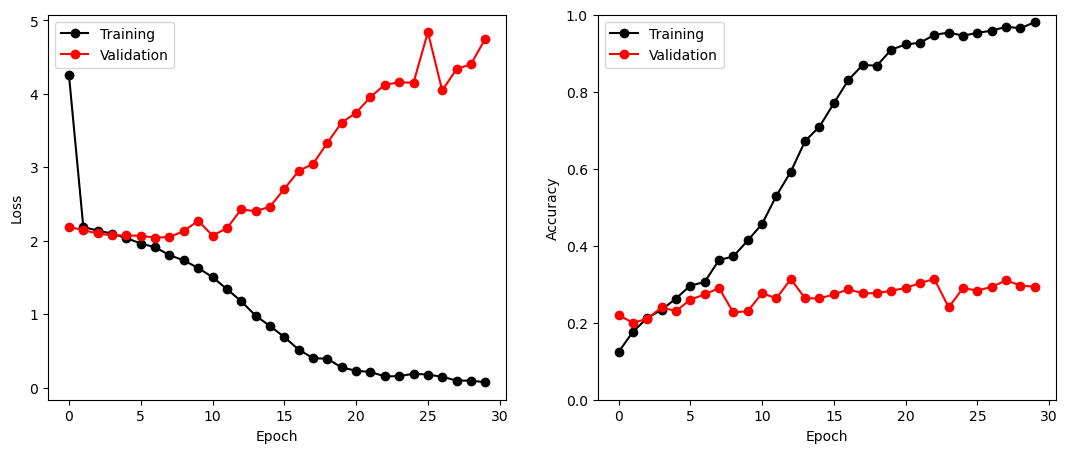

In [38]:
bird_results = pd.read_csv(bird_logger.experiment.metrics_file_path)

fig, axes = subplots(1, 2, figsize=(13, 5))

# loss curves: a growing gap between training (black) and validation (red) signals overfitting
ax = summary_plot(bird_results, axes[0], col='loss', ylabel='Loss')
ax.set_xticks(np.linspace(0, 30, 7).astype(int))

# accuracy curves
ax = summary_plot(bird_results, axes[1], col='accuracy', ylabel='Accuracy')
ax.set_ylim([0, 1])
ax.set_xticks(np.linspace(0, 30, 7).astype(int))

### Cleanup

We delete the objects we created above to free memory.

In [ ]:
del(full_dataset, bird_train, bird_test,
    bird_dm, bird_model, bird_optimizer,
    bird_module, bird_trainer, bird_results)